In [1]:
from autoslo.filesystem.logging import query_latencies_from_log
from pathlib import Path
import pandas as pd
import autoslo.filesystem.path_utils as pu
from autoslo.workload_execution.trace import Trace


In [2]:
run_dir = Path(pu.get_data_path()) / "runs" / "1778469201294"

client_side = query_latencies_from_log(run_dir / "structured_log.parquet")

In [3]:
client_side

,query_id,query_text_id,arrival_s,completion_s,latency_s
0,query_0,ext_tpcds1000#035#001,-29.980258,-11.059028,18.921230
1,query_1,ext_tpcds1000#017#001,-11.057997,1.182472,12.240469
2,query_10,ext_tpcds1000#044#001,208.211590,239.774232,31.562642
3,query_100,ext_tpcds1000#019#001,1132.596151,1133.115687,0.519536
4,query_101,ext_tpcds1000#060#001,1133.116416,1133.836058,0.719642
...,...,...,...,...,...
292,query_95,ext_tpcds1000#083#001,1013.219746,1013.743489,0.523743
293,query_96,ext_tpcds1000#077#001,1013.743949,1014.900224,1.156275
294,query_97,ext_tpcds1000#023#001,1014.901186,1119.864691,104.963505
295,query_98,ext_tpcds1000#066#001,1119.865164,1122.435768,2.570604


In [4]:
trace = Trace("1778469201294")
server_side = trace.latencies_s
server_side

query_id
autoslo-16-1778469202-0_3181#d9382381-3784-4410-baea-2ea009eabc6e     18.883222
autoslo-16-1778469202-0_3190#d9382381-3784-4410-baea-2ea009eabc6e     12.178989
autoslo-16-1778469202-0_3197#d9382381-3784-4410-baea-2ea009eabc6e     16.306485
autoslo-16-1778469202-0_3212#d9382381-3784-4410-baea-2ea009eabc6e      9.012146
autoslo-16-1778469202-0_3223#d9382381-3784-4410-baea-2ea009eabc6e    135.442648
                                                                        ...    
autoslo-16-1778469202-0_5983#d9382381-3784-4410-baea-2ea009eabc6e      5.807837
autoslo-16-1778469202-0_5991#d9382381-3784-4410-baea-2ea009eabc6e      2.229778
autoslo-16-1778469202-0_5998#d9382381-3784-4410-baea-2ea009eabc6e      1.568733
autoslo-16-1778469202-0_6003#d9382381-3784-4410-baea-2ea009eabc6e     13.516724
autoslo-16-1778469202-0_6010#d9382381-3784-4410-baea-2ea009eabc6e      3.306722
Name: elapsed_time, Length: 297, dtype: float64

In [5]:
trace.query_id_mapping

query_id
autoslo-16-1778469202-0_3181#d9382381-3784-4410-baea-2ea009eabc6e      query_0
autoslo-16-1778469202-0_3190#d9382381-3784-4410-baea-2ea009eabc6e      query_1
autoslo-16-1778469202-0_3197#d9382381-3784-4410-baea-2ea009eabc6e      query_2
autoslo-16-1778469202-0_3212#d9382381-3784-4410-baea-2ea009eabc6e      query_3
autoslo-16-1778469202-0_3223#d9382381-3784-4410-baea-2ea009eabc6e      query_4
                                                                       ...    
autoslo-16-1778469202-0_5983#d9382381-3784-4410-baea-2ea009eabc6e    query_292
autoslo-16-1778469202-0_5991#d9382381-3784-4410-baea-2ea009eabc6e    query_293
autoslo-16-1778469202-0_5998#d9382381-3784-4410-baea-2ea009eabc6e    query_294
autoslo-16-1778469202-0_6003#d9382381-3784-4410-baea-2ea009eabc6e    query_295
autoslo-16-1778469202-0_6010#d9382381-3784-4410-baea-2ea009eabc6e    query_296
Name: workload_query_id, Length: 297, dtype: object

In [6]:
merged = pd.merge(server_side, trace.query_id_mapping, on="query_id", how="left").reset_index()
merged

,query_id,elapsed_time,workload_query_id
0,autoslo-16-1778469202-0_3181#d9382381-3784-441...,18.883222,query_0
1,autoslo-16-1778469202-0_3190#d9382381-3784-441...,12.178989,query_1
2,autoslo-16-1778469202-0_3197#d9382381-3784-441...,16.306485,query_2
3,autoslo-16-1778469202-0_3212#d9382381-3784-441...,9.012146,query_3
4,autoslo-16-1778469202-0_3223#d9382381-3784-441...,135.442648,query_4
...,...,...,...
292,autoslo-16-1778469202-0_5983#d9382381-3784-441...,5.807837,query_292
293,autoslo-16-1778469202-0_5991#d9382381-3784-441...,2.229778,query_293
294,autoslo-16-1778469202-0_5998#d9382381-3784-441...,1.568733,query_294
295,autoslo-16-1778469202-0_6003#d9382381-3784-441...,13.516724,query_295


In [12]:
merged2 = pd.merge(merged, client_side, left_on='workload_query_id', right_on='query_id', how='left')
merged2

,query_id_x,elapsed_time,workload_query_id,query_id_y,query_text_id,arrival_s,completion_s,latency_s
0,autoslo-16-1778469202-0_3181#d9382381-3784-441...,18.883222,query_0,query_0,ext_tpcds1000#035#001,-29.980258,-11.059028,18.921230
1,autoslo-16-1778469202-0_3190#d9382381-3784-441...,12.178989,query_1,query_1,ext_tpcds1000#017#001,-11.057997,1.182472,12.240469
2,autoslo-16-1778469202-0_3197#d9382381-3784-441...,16.306485,query_2,query_2,ext_tpcds1000#025#001,1.184875,17.553956,16.369081
3,autoslo-16-1778469202-0_3212#d9382381-3784-441...,9.012146,query_3,query_3,ext_tpcds1000#090#001,17.555208,26.619987,9.064779
4,autoslo-16-1778469202-0_3223#d9382381-3784-441...,135.442648,query_4,query_4,ext_tpcds1000#078#001,26.622088,162.117673,135.495585
...,...,...,...,...,...,...,...,...
292,autoslo-16-1778469202-0_5983#d9382381-3784-441...,5.807837,query_292,query_292,ext_tpcds1000#002#001,3101.230359,3107.150630,5.920271
293,autoslo-16-1778469202-0_5991#d9382381-3784-441...,2.229778,query_293,query_293,ext_tpcds1000#029#001,3107.151338,3109.444755,2.293417
294,autoslo-16-1778469202-0_5998#d9382381-3784-441...,1.568733,query_294,query_294,ext_tpcds1000#063#001,3109.445640,3111.067237,1.621597
295,autoslo-16-1778469202-0_6003#d9382381-3784-441...,13.516724,query_295,query_295,ext_tpcds1000#093#001,3111.068101,3124.638551,13.570450


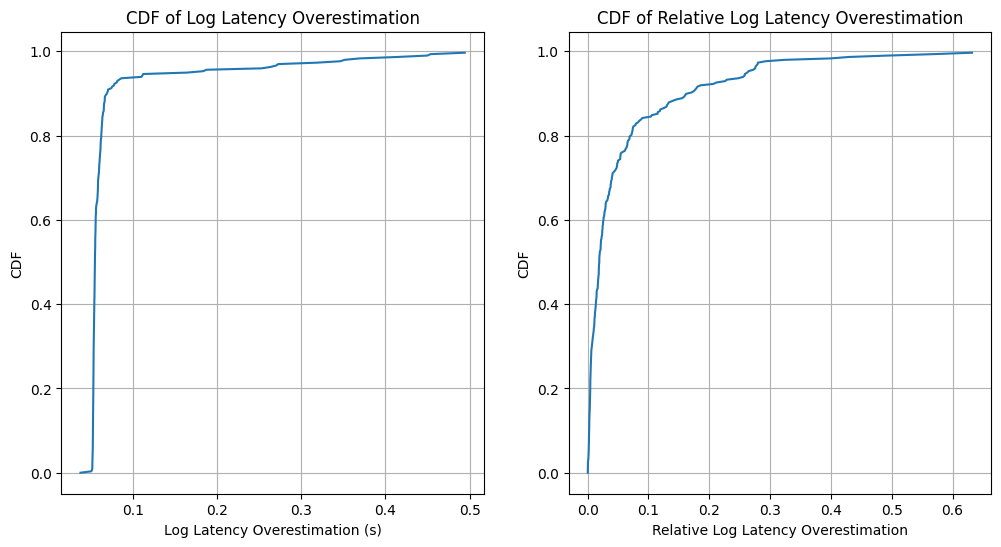

In [15]:
merged2['latency_overestimation_in_log'] = merged2['latency_s'] - merged2['elapsed_time']
merged2['relative_latency_overestimation_in_log'] = merged2['latency_overestimation_in_log'] / merged2['elapsed_time']

# Plot a cdf of the log latency overestimation
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
yvals = np.arange(len(merged2)) / float(len(merged2))
ax[0].plot(merged2['latency_overestimation_in_log'].sort_values(ascending=True), yvals)
ax[0].set_xlabel('Log Latency Overestimation (s)')
ax[0].set_ylabel('CDF')
ax[0].set_title('CDF of Log Latency Overestimation')
ax[0].grid()

ax[1].plot(merged2['relative_latency_overestimation_in_log'].sort_values(ascending=True), yvals)
ax[1].set_xlabel('Relative Log Latency Overestimation')
ax[1].set_ylabel('CDF')
ax[1].set_title('CDF of Relative Log Latency Overestimation')
ax[1].grid()


plt.show()